# Decision Tree (Classification) with scikit-learn

This notebook uses a real dataset (Iris) to show: model training, tuning,
and a tree visualization.


In [105]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

np.set_printoptions(precision=3, suppress=True)


## 1) Load a real dataset
We use the classic Iris dataset with 3 classes and 4 features.


In [92]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(y_train)

[0 2 1 0 1 2 1 2 2 2 2 1 1 1 1 0 0 2 2 0 1 0 2 0 1 2 2 0 2 0 0 1 1 0 2 2 1
 1 2 1 0 1 0 2 0 0 2 0 0 0 0 1 2 1 0 2 1 2 0 2 0 1 2 0 1 1 2 1 1 2 0 0 0 2
 1 2 1 2 2 1 0 2 1 0 2 0 2 1 1 0 1 2 0 0 2 2 2 1 2 0 2 1 2 2 0 1 1 1 1 1 0
 2 1 1 0 0 0 0 1 0]


## 2) Base model (default parameters)
This is a baseline accuracy to compare against tuning.


In [93]:
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

train_pred = base_model.predict(X_train)
test_pred = base_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print('Base train accuracy:', train_acc)
print('Base test accuracy:', test_acc)


Base train accuracy: 1.0
Base test accuracy: 0.9333333333333333


## 3) Hyperparameter tuning
We tune `max_depth` and `min_samples_split`.
If a parameter **does not change** accuracy, the constraint may not be active
for this dataset (e.g., the tree is already shallow).


In [94]:
results = []

for max_depth in [1, 2, 3, 4, None]:
    for min_samples_split in [2, 5, 10]:
        model = DecisionTreeClassifier(
            random_state=42,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
        )
        model.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        results.append((max_depth, min_samples_split, train_acc, test_acc))

for max_depth, min_samples_split, train_acc, test_acc in results:
    print(
        f'max_depth={max_depth}, min_samples_split={min_samples_split} -> '
        f'train={train_acc:.3f}, test={test_acc:.3f}'
    )


# task 1: Use GridSearchCV to find the best hyperparameters for the DecisionTreeClassifier on the Iris dataset.

max_depth=1, min_samples_split=2 -> train=0.667, test=0.667
max_depth=1, min_samples_split=5 -> train=0.667, test=0.667
max_depth=1, min_samples_split=10 -> train=0.667, test=0.667
max_depth=2, min_samples_split=2 -> train=0.967, test=0.933
max_depth=2, min_samples_split=5 -> train=0.967, test=0.933
max_depth=2, min_samples_split=10 -> train=0.967, test=0.933
max_depth=3, min_samples_split=2 -> train=0.983, test=0.967
max_depth=3, min_samples_split=5 -> train=0.983, test=0.967
max_depth=3, min_samples_split=10 -> train=0.983, test=0.967
max_depth=4, min_samples_split=2 -> train=0.992, test=0.933
max_depth=4, min_samples_split=5 -> train=0.983, test=0.967
max_depth=4, min_samples_split=10 -> train=0.983, test=0.967
max_depth=None, min_samples_split=2 -> train=1.000, test=0.933
max_depth=None, min_samples_split=5 -> train=0.983, test=0.967
max_depth=None, min_samples_split=10 -> train=0.983, test=0.967


In [95]:
# task 1: Use GridSearchCV to find the best hyperparameters for the DecisionTreeClassifier on the Iris dataset.

from sklearn.model_selection import GridSearchCV

def gridsearch_for_dtr(X_train, y_train):
    param_grid = {
        'criterion': ['gini', 'entropy'],
        'max_depth':[4,5,8,20,30,None],
        'min_samples_split':[2,3,8,10,12,20],
        'min_samples_leaf':[1,5,12,20]
    }

    grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, verbose=1)
    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    print("Best hyperparameters:", best_params)
    return best_params

def dtr_evaluate_model(X_train, y_train):
    best_params = gridsearch_for_dtr(X_train, y_train)

    # you can re-train the model with the best hyperparameters
    best_model = DecisionTreeClassifier(**best_params)
    best_model.fit(X_train, y_train)

    # evaluate the model
    y_pred_best = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_best)
    print("Accuracy with best hyperparameters:", accuracy)

dtr_evaluate_model(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best hyperparameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy with best hyperparameters: 0.9666666666666667


## 4) Visualize the tree
We plot a small tree to inspect split rules.


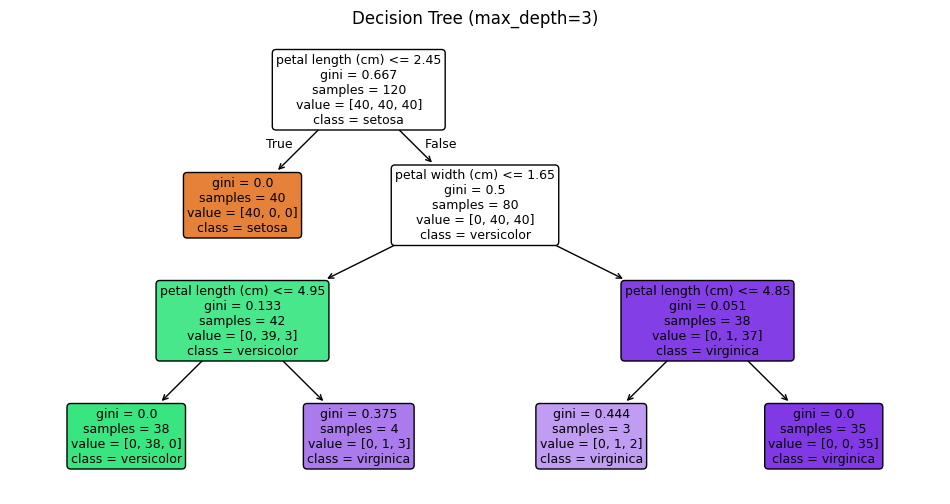

In [96]:
viz_model = DecisionTreeClassifier(random_state=42, max_depth=3)
viz_model.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
plot_tree(
    viz_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title('Decision Tree (max_depth=3)')
plt.show()


In [110]:
#Task 2  train DT_ R with categorical variable and plot the tree ( Observe how categorical variables are handled)
import numpy as np
import pandas as pd
from sklearn.calibration import LabelEncoder

data ={
    'product_cat': np.random.choice(['A', 'B', 'C'], size=5000),
    'price': np.random.rand(5000) * 100,
    'rating': np.random.rand(5000) * 5,
    'Target': np.random.choice([True, False], size=5000)
}

df = pd.DataFrame(data)
df.head()

encoder = LabelEncoder()
df["product_cat"] = encoder.fit_transform(df["product_cat"])
# df["Target"] = encoder.fit_transform(df["Target"]) it is wrong to encode target like this for boolean
df.head()

,product_cat,price,rating,Target
0,1,77.513545,4.388325,True
1,1,61.451950,3.994354,True
2,1,45.960366,0.182711,True
3,2,86.628300,1.679778,True
4,1,70.358189,1.393287,False


In [111]:
X = df.drop('Target', axis=1)
y = df.Target.astype('int')
feature_names = X.columns.tolist()
class_names = ['Yes', 'No']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(y_train)

2798    0
658     1
2592    1
497     1
4733    0
       ..
482     1
3157    0
565     0
4634    1
4006    1
Name: Target, Length: 4000, dtype: int64


In [112]:
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

train_pred = base_model.predict(X_train)
test_pred = base_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print('Base train accuracy:', train_acc)
print('Base test accuracy:', test_acc)

Base train accuracy: 1.0
Base test accuracy: 0.509


In [113]:
# Use GridSearchCV
dtr_evaluate_model(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Accuracy with best hyperparameters: 0.514


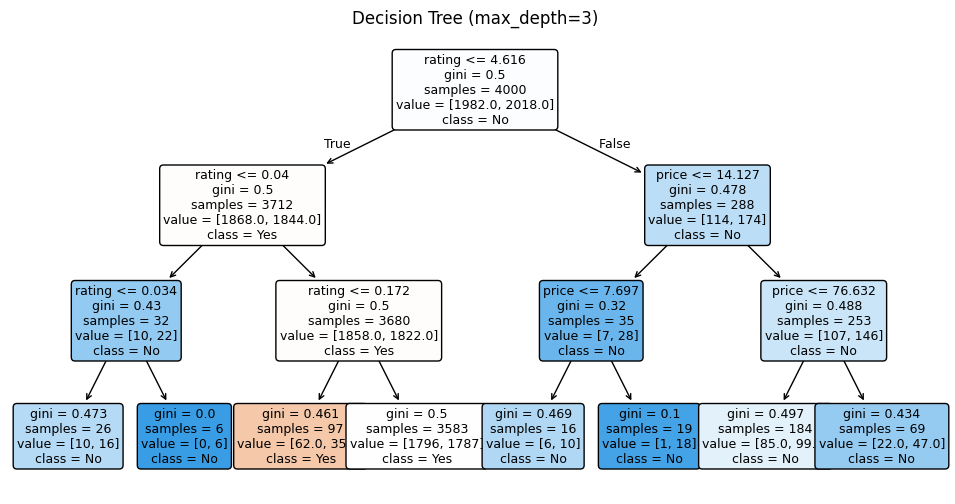

In [114]:
viz_model = DecisionTreeClassifier(random_state=42, max_depth=3)
viz_model.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
plot_tree(
    viz_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title('Decision Tree (max_depth=3)')
plt.show()
